# Automatic Review Analyzer

The goal of this project is to build a classifier for sentiment analysis of product reviews. The data consists of review text together with labels on a $+1/-1$ scale, where $+1$ represents a positive review and $-1$ represents a negative review. The project compares three linear classifiers:

- Perceptron
- Average Perceptron
- Pegasos

The workflow is to translate reviews into feature vectors, train the classifiers, measure accuracy, tune the relevant hyperparameters, evaluate the final model on held-out test data, and inspect which words are most influential for positive and negative classification.

## Reference

S. Shalev-Shwartz, Y. Singer, N. Srebro, A. Cotter - [*Pegasos: Primal Estimated sub-GrAdient SOlver for SVM*](https://home.ttic.edu/~nati/Publications/PegasosMPB.pdf)

## Project structure and how to run this notebook

Before running the notebook, keep the project files in the following folder structure:

```text
Automatic Review Analyzer/
├── README.md
├── Automatic Review Analyzer.ipynb
└── source/
    ├── core.py
    ├── utils.py
    └── data/
        ├── reviews_train.tsv
        ├── reviews_val.tsv
        ├── reviews_test.tsv
        ├── toy_data.tsv
        └── stopwords.txt
```

The notebook is the main file to read and run. The `source/` folder contains the implementation and helper functions:

- `core.py` contains the learning algorithms, classification rule, accuracy function, and bag-of-words feature construction.
- `utils.py` contains helper functions for loading data, plotting toy examples, tuning hyperparameters, and inspecting explanatory word features.
- `data/` contains the train, validation, test, toy, and stopword files used by the notebook.

The file locations are important. The notebook loads the data using paths of the form

```python
ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "source" / "data"
```

Therefore, run the notebook from the root project folder, where the notebook and the `source/` folder are side by side. Do not move, rename, or separate the `source/` folder or the files inside `source/data/`, otherwise the imports and data-loading steps will not work. The required external Python packages are:

```bash
pip install numpy matplotlib jupyter
```

The remaining modules used in the project, such as `pathlib`, `csv`, `random`, `string`, and `sys`, are part of the Python standard library. To run the project locally open the `Automatic Review Analyzer.ipynb` Jupyter notebook and run all cells from the beginning. The notebook should be read from top to bottom: it first loads the review data, translates reviews into bag-of-words feature vectors, compares the linear classifiers, tunes hyperparameters, evaluates the selected model on the test set, inspects explanatory words, and finally studies simple feature-engineering variants.

## Classification setting

Let the labeled review dataset be

$$
\mathcal{D}=\left\{\left(x^{(i)},\, y^{(i)}\right)\right\}_{i=1}^{n},
\qquad
 y^{(i)}\in\{-1,+1\}.
$$

Here $x^{(i)}$ is the review text and $y^{(i)}$ is its sentiment label. The main task is to learn a rule that assigns a positive or negative label to a new review. The project proceeds in the following steps:

- convert review text into numerical features
- implement and compare the Perceptron, Average Perceptron, and Pegasos classifiers
- use these classifiers on the review dataset
- tune the hyperparameters using validation accuracy
- evaluate the selected classifier on the test set
- experiment with simple changes to the feature representation

## Setup

The next cell imports the numerical, plotting, and project-specific modules. NumPy is used for matrix and vector computations, while Matplotlib is used for visualizing decision boundaries and tuning results. The notebook assumes the following project structure:

- `source/core.py` contains the learning algorithms and feature-extraction functions,
- `source/utils.py` contains the data-loading, plotting, and tuning utilities,
- `source/data/` contains the review datasets, toy dataset, and stopword file.



In [1]:
import numpy as np
import matplotlib.pyplot as plt
from source import core
from source import utils

from pathlib import Path
ROOT_DIR = Path.cwd()
DATA_DIR = ROOT_DIR / "source" / "data"

## The data

The review data has already been split into training, validation, and test files:

- `reviews_train.tsv`,
- `reviews_val.tsv`,
- `reviews_test.tsv`.

The training set is used to fit the model parameters. The validation set is used to choose between algorithms and hyperparameters. The test set is kept as a final held-out benchmark after the model choice has already been made. The next cell reads the `.tsv` files and separates the raw review text from the corresponding sentiment labels.

In [2]:
# -------------------------------------------------------------------------------
# Load the training, validation, and test datasets
# -------------------------------------------------------------------------------

train_data = utils.load_data(DATA_DIR / 'reviews_train.tsv')
val_data = utils.load_data(DATA_DIR / 'reviews_val.tsv')
test_data = utils.load_data(DATA_DIR / 'reviews_test.tsv')

train_texts, train_labels = zip(*((sample['text'], sample['sentiment']) for sample in train_data))
val_texts, val_labels = zip(*((sample['text'], sample['sentiment']) for sample in val_data))
test_texts, test_labels = zip(*((sample['text'], sample['sentiment']) for sample in test_data))

## Translating reviews to feature vectors

We convert review texts into feature vectors using a **bag-of-words** representation. First, the words appearing in the training reviews are collected into a dictionary

$$
V=\{w_1,w_2,\dots,w_p\},
$$

where $p$ is the number of unique words retained in the dictionary. Each review is then represented by a vector

$$
x^{(i)}=\bigl(x_1^{(i)},x_2^{(i)},\dots,x_p^{(i)}\bigr)^\top \in \mathbb{R}^p.
$$

For the first feature representation, the $j$-th coordinate is binary:

$$
x_j^{(i)}=
\begin{cases}
1, & \text{if word } w_j \text{ appears in review } i,\\[4pt]
0, & \text{otherwise.}
\end{cases}
$$

Thus the text-classification task becomes a standard supervised learning problem with a feature matrix, a label vector, and linear classifiers.



In [3]:
# Build a bag-of-words dictionary from the training texts
dictionary = core.bag_of_words(train_texts)

train_bow_features = core.extract_bow_feature_vectors(train_texts, dictionary)
val_bow_features = core.extract_bow_feature_vectors(val_texts, dictionary)
test_bow_features = core.extract_bow_feature_vectors(test_texts, dictionary)

## Linear classification rule

All three algorithms use the same linear hypothesis. Given a feature vector $x$, the score of the classifier is

$$
s(x)=\theta\cdot x+\theta_0,
$$

where $\theta$ is the feature-coefficient vector and $\theta_0$ is the offset parameter. The predicted label is determined by the sign of this score:

$$
\hat y(x)=\operatorname{sign}\!\left(\theta\cdot x+\theta_0\right).
$$

The margin quantity

$$
y^{(i)}\left(\theta\cdot x^{(i)}+\theta_0\right)
$$

will appear repeatedly. It is positive when the example is classified correctly and nonpositive when it is misclassified or exactly on the decision boundary.

## Perceptron

The Perceptron updates only when the current example is misclassified or lies exactly on the boundary. Its update logic can be summarized as

$$
\begin{aligned}
&\textbf{Perceptron}\!\left(\{(x^{(i)},y^{(i)})\}_{i=1}^n,\,T\right) \\[4pt]
&\qquad \theta \leftarrow 0,\qquad \theta_0 \leftarrow 0 \\[4pt]
&\qquad \text{for } t=1,\dots,T \\[2pt]
&\qquad\qquad \text{for } i=1,\dots,n \\[2pt]
&\qquad\qquad\qquad \text{if } y^{(i)}\bigl(\theta \cdot x^{(i)}+\theta_0\bigr)\le 0 \\[2pt]
&\qquad\qquad\qquad\qquad \theta \leftarrow \theta + y^{(i)}x^{(i)} \\[2pt]
&\qquad\qquad\qquad\qquad \theta_0 \leftarrow \theta_0 + y^{(i)}.
\end{aligned}
$$

So the Perceptron changes the boundary only when it makes a mistake.

## Average Perceptron

Average Perceptron uses the **same single-step update** as the ordinary Perceptron, but instead of returning only the last iterate, it averages the parameters collected over the training process. If the intermediate iterates are

$$
(\theta^{(1)},\theta_0^{(1)}),\,
(\theta^{(2)},\theta_0^{(2)}),\,
\dots,\,
(\theta^{(m)},\theta_0^{(m)}),
$$

then the returned parameters are

$$
\bar\theta=\frac{1}{m}\sum_{r=1}^{m}\theta^{(r)},
\qquad
\bar\theta_0=\frac{1}{m}\sum_{r=1}^{m}\theta_0^{(r)}.
$$

A compact pseudocode description is

$$
\begin{aligned}
&\textbf{Average-Perceptron}\!\left(\{(x^{(i)},y^{(i)})\}_{i=1}^n,\,T\right) \\[4pt]
&\qquad \theta \leftarrow 0,\qquad \theta_0 \leftarrow 0 \\[2pt]
&\qquad s \leftarrow 0,\qquad s_0 \leftarrow 0,\qquad c \leftarrow 0 \\[4pt]
&\qquad \text{repeat the Perceptron update rule for } T \text{ passes} \\[2pt]
&\qquad \text{after each step, accumulate } s \leftarrow s+\theta,\; s_0 \leftarrow s_0+\theta_0,\; c \leftarrow c+1 \\[4pt]
&\qquad \text{return } \bar\theta = s/c,\qquad \bar\theta_0=s_0/c.
\end{aligned}
$$

## Pegasos

Pegasos is the model in the notebook with the clearest optimization interpretation. It targets the regularized hinge-loss objective

$$
J(\theta,\theta_0)
=
\frac{1}{n}\sum_{i=1}^{n}
\mathrm{Loss}_h\!\left(y^{(i)}\bigl(\theta \cdot x^{(i)}+\theta_0\bigr)\right)
+
\frac{\lambda}{2}\lVert \theta \rVert_2^2,
$$

where

$$
\mathrm{Loss}_h(z)=\max(0,\,1-z).
$$

The project implementation uses the learning-rate schedule

$$
\eta_t=\frac{1}{\sqrt{t}},
$$

so its update rule is

$$
\begin{aligned}
&\textbf{Pegasos}\!\left(\{(x^{(i)},y^{(i)})\}_{i=1}^n,\,T,\,\lambda\right) \\[4pt]
&\qquad \theta \leftarrow 0,\qquad \theta_0 \leftarrow 0,\qquad t \leftarrow 0 \\[4pt]
&\qquad \text{for each pass through the data} \\[2pt]
&\qquad\qquad \text{for each training example } (x^{(i)},y^{(i)}) \\[2pt]
&\qquad\qquad\qquad t \leftarrow t+1,\qquad \eta_t \leftarrow 1/\sqrt{t} \\[2pt]
&\qquad\qquad\qquad \text{if } y^{(i)}\bigl(\theta \cdot x^{(i)}+\theta_0\bigr)\le 1 \\[2pt]
&\qquad\qquad\qquad\qquad \theta \leftarrow (1-\eta_t \lambda)\theta + \eta_t y^{(i)}x^{(i)} \\[2pt]
&\qquad\qquad\qquad\qquad \theta_0 \leftarrow \theta_0 + \eta_t y^{(i)} \\[2pt]
&\qquad\qquad\qquad \text{else} \\[2pt]
&\qquad\qquad\qquad\qquad \theta \leftarrow (1-\eta_t \lambda)\theta.
\end{aligned}
$$

Because the trigger is
$
y^{(i)}\bigl(\theta \cdot x^{(i)}+\theta_0\bigr)\le 1,
$
Pegasos updates not only on outright mistakes, but also on points that are classified with insufficient margin.

## Toy dataset and geometric intuition

Before moving to the high-dimensional text data, the notebook visualizes all three algorithms on a simple 2D toy dataset. In 2D, if $x=(x_1,x_2)$ and $\theta=(\theta_1,\theta_2)$, then the decision boundary is

$$
\theta \cdot x+\theta_0=0
\quad \Longleftrightarrow \quad
\theta_1 x_1+\theta_2 x_2+\theta_0=0.
$$

Solving for $x_2$ gives

$$
x_2=-\frac{\theta_1 x_1+\theta_0}{\theta_2}=-\frac{\theta_1}{\theta_2}x_1-\frac{\theta_0}{\theta_2},
$$

which is why the boundary can be plotted directly once $(\theta,\theta_0)$ is known.

theta for Perceptron is 1.8809999999999982, 3.8159999999999963
theta_0 for Perceptron is -5.0


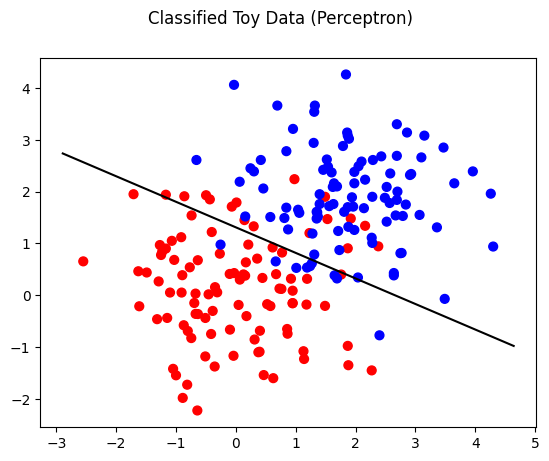

theta for Average Perceptron is 2.425476, 2.6097040000000176
theta_0 for Average Perceptron is -4.732


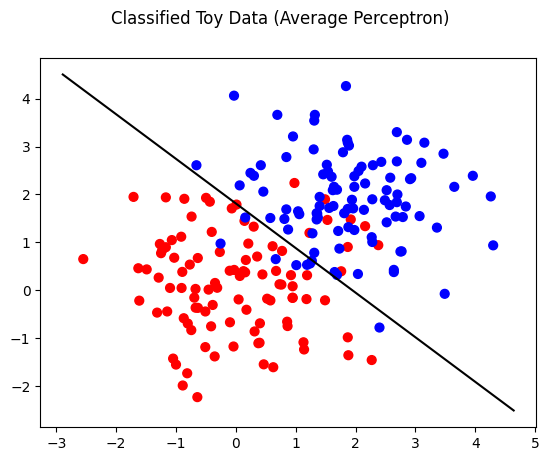

theta for Pegasos is 0.6878962360013456, 0.7620653856493942
theta_0 for Pegasos is -1.1216660077128084


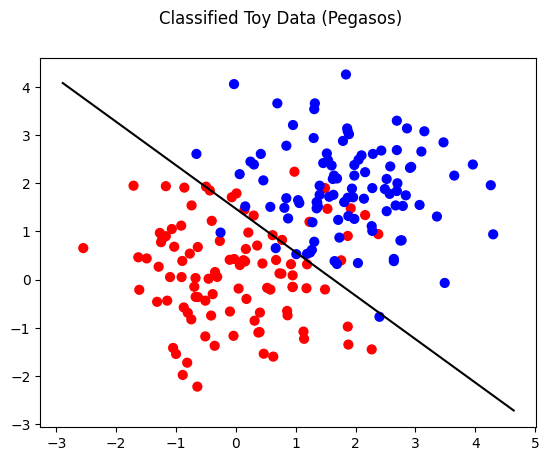

In [4]:
# -------------------------------------------------------------------------------
# Toy dataset visualization
# -------------------------------------------------------------------------------

toy_features, toy_labels = toy_data = utils.load_toy_data(DATA_DIR / 'toy_data.tsv')

T = 10
L = 0.2

thetas_perceptron = core.perceptron(toy_features, toy_labels, T)
thetas_avg_perceptron = core.average_perceptron(toy_features, toy_labels, T)
thetas_pegasos = core.pegasos(toy_features, toy_labels, T, L)

def plot_toy_results(algo_name, thetas):
    print('theta for', algo_name, 'is', ', '.join(map(str,list(thetas[0]))))
    print('theta_0 for', algo_name, 'is', str(thetas[1]))
    utils.plot_toy_data(algo_name, toy_features, toy_labels, thetas)

plot_toy_results('Perceptron', thetas_perceptron)
plot_toy_results('Average Perceptron', thetas_avg_perceptron)
plot_toy_results('Pegasos', thetas_pegasos)

## Parameter evolution

The next block records how the learned parameters change as the number of passes through the toy dataset increases. For each value of $T$, the code computes the corresponding parameters

$$
\theta_1^{(T)},\qquad \theta_2^{(T)},\qquad \theta_0^{(T)}.
$$

Plotting these values gives a simple way to see whether the parameter estimates are stabilizing as the number of iterations grows.

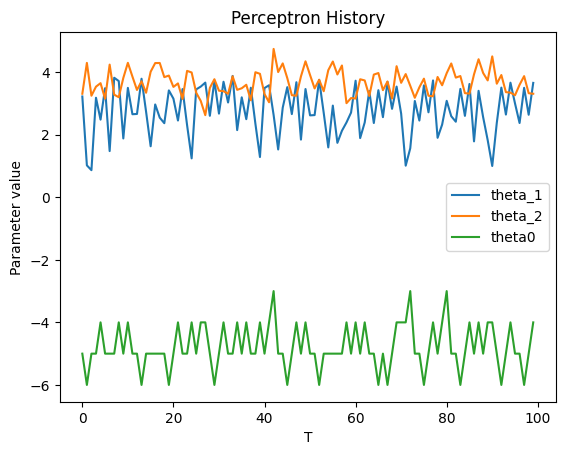

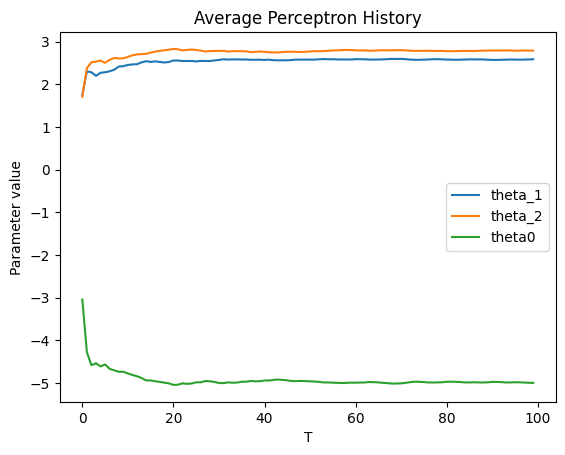

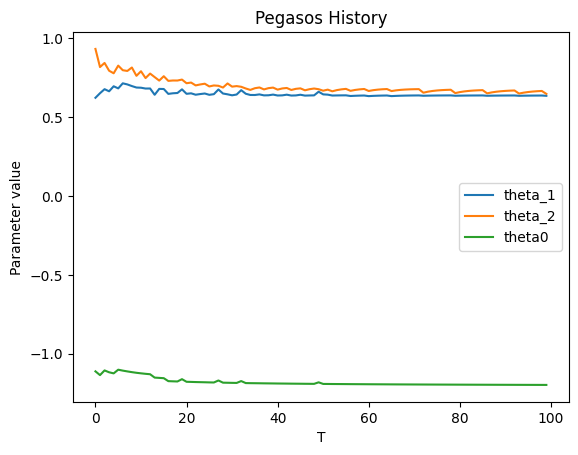

In [5]:
# Parameter evolution on the toy dataset

def perceptron_history(T_max):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = core.perceptron(toy_features, toy_labels, T)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])
    return theta_history, theta0_history

def average_perceptron_history(T_max):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = core.average_perceptron(toy_features, toy_labels, T)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])

    return theta_history, theta0_history

def pegasos_history(T_max, L):
    theta_history = []
    theta0_history = []
    for T in range(1, T_max+1):
        thetas = core.pegasos(toy_features, toy_labels, T, L)
        theta_history.append(thetas[0])
        theta0_history.append(thetas[1])
    return theta_history, theta0_history

def plot_parameter_history(theta_history, theta0_history, title):
    theta_history = np.array(theta_history)   # shape (num_updates, 2)
    theta0_history = np.array(theta0_history) # shape (num_updates,)
    plt.figure()
    plt.plot(theta_history[:, 0], label='theta_1')
    plt.plot(theta_history[:, 1], label='theta_2')
    plt.plot(theta0_history, label='theta0')
    plt.xlabel('T')
    plt.ylabel('Parameter value')
    plt.title(title)
    plt.legend()
    plt.show()

T_max = 100
L = 0.2

theta_history, theta0_history = perceptron_history(T_max)
plot_parameter_history(theta_history, theta0_history, 'Perceptron History')

theta_history, theta0_history = average_perceptron_history(T_max)
plot_parameter_history(theta_history, theta0_history, 'Average Perceptron History')

theta_history, theta0_history = pegasos_history(T_max, L)
plot_parameter_history(theta_history, theta0_history, 'Pegasos History')

## Classification and baseline accuracy

Now that the learning algorithms are available, we need a way to use the learned parameters to classify review feature vectors and measure performance. The accuracy function compares predicted labels with true labels:

$$
\mathrm{Acc}(\hat y,y)=
\frac{1}{n}\sum_{i=1}^{n}\mathbf{1}\{\hat y^{(i)}=y^{(i)}\}.
$$

The next cell trains the three classifiers using the same initial hyperparameter choice and reports both training and validation accuracy. This gives a baseline comparison before tuning.



In [6]:
# -------------------------------------------------------------------------------
# Baseline comparison on the review dataset
# -------------------------------------------------------------------------------

T = 10
L = 0.01

pct_train_accuracy, pct_val_accuracy = \
   core.classifier_accuracy(core.perceptron, train_bow_features,val_bow_features,train_labels,val_labels,T=T)
print("{:35} {:.4f}".format("Training accuracy for perceptron:", pct_train_accuracy))
print("{:35} {:.4f}".format("Validation accuracy for perceptron:", pct_val_accuracy))

avg_pct_train_accuracy, avg_pct_val_accuracy = \
   core.classifier_accuracy(core.average_perceptron, train_bow_features,val_bow_features,train_labels,val_labels,T=T)
print("{:43} {:.4f}".format("Training accuracy for average perceptron:", avg_pct_train_accuracy))
print("{:43} {:.4f}".format("Validation accuracy for average perceptron:", avg_pct_val_accuracy))

avg_peg_train_accuracy, avg_peg_val_accuracy = \
   core.classifier_accuracy(core.pegasos, train_bow_features,val_bow_features,train_labels,val_labels,T=T,L=L)
print("{:32} {:.4f}".format("Training accuracy for Pegasos:", avg_peg_train_accuracy))
print("{:32} {:.4f}".format("Validation accuracy for Pegasos:", avg_peg_val_accuracy))

Training accuracy for perceptron:   0.9293
Validation accuracy for perceptron: 0.7620
Training accuracy for average perceptron:   0.9770
Validation accuracy for average perceptron: 0.7960
Training accuracy for Pegasos:   0.9042
Validation accuracy for Pegasos: 0.7960


### Baseline comparison results

With the initial choice $T=10$ and $\lambda=0.01$ for Pegasos, the validation accuracies are:

| Algorithm | Training accuracy | Validation accuracy |
|---|---:|---:|
| Perceptron | $0.9293$ | $0.7620$ |
| Average Perceptron | $0.9770$ | $0.7960$ |
| Pegasos | $0.9042$ | $0.7960$ |

The baseline comparison shows that the Average Perceptron and Pegasos perform better than the ordinary Perceptron on the validation set. The ordinary Perceptron has lower validation accuracy, which is expected because it can be sensitive to the order of updates and to later parameter changes. The Average Perceptron stabilizes the Perceptron updates by averaging parameter values, while Pegasos combines hinge loss, regularization, and a decaying learning rate. At this baseline stage, both of these approaches give the best validation performance.

## Parameter tuning

The algorithms are now running, but the values of hyperparameters such as $T$ and $\lambda$ still need to be chosen. The validation set is used for this purpose. For Perceptron and Average Perceptron, we tune the number of passes through the feature matrix:

$$
T^*=\operatorname*{arg\,max}_{T\in\mathcal{T}}
\mathrm{Acc}_{\mathrm{val}}(T).
$$

For Pegasos, there are two hyperparameters: the number of passes $T$ and the regularization parameter $\lambda$. The notebook performs a full grid search over the finite set $\mathcal{T}\times\Lambda$:

$$
(T^*,\lambda^*)=
\operatorname*{arg\,max}_{(T,\lambda)\in\mathcal{T}\times\Lambda}
\mathrm{Acc}_{\mathrm{val}}(T,\lambda).
$$

This gives a direct comparison of all candidate $(T,\lambda)$ pairs in the chosen grid.



## Tuning procedure

For a finite list of candidate values, tuning means training a model for each candidate and keeping track of the training and validation accuracies. For Perceptron and Average Perceptron:

$$
\begin{aligned}
&\textbf{Tune}(\mathcal{T})\\[4pt]
&\qquad \text{for each } T\in\mathcal{T}\\[2pt]
&\qquad\qquad \text{train the classifier with } T\\[2pt]
&\qquad\qquad \text{compute training and validation accuracy}\\[2pt]
&\qquad \text{return the } T \text{ with the best validation accuracy.}
\end{aligned}
$$

For Pegasos:

$$
\begin{aligned}
&\textbf{Tune-Pegasos}(\mathcal{T},\Lambda)\\[4pt]
&\qquad \text{for each } T\in\mathcal{T}\\[2pt]
&\qquad\qquad \text{for each } \lambda\in\Lambda\\[2pt]
&\qquad\qquad\qquad \text{train Pegasos with } (T,\lambda)\\[2pt]
&\qquad\qquad\qquad \text{compute training and validation accuracy}\\[2pt]
&\qquad \text{return the pair } (T^*,\lambda^*) \text{ with the best validation accuracy.}
\end{aligned}
$$

The plots summarize how validation performance changes as the hyperparameter values are varied.

Best Perceptron: Accuracy = 0.7820, T=25.0000
Best Average Perceptron: Accuracy = 0.8020, T=15.0000
Best Pegasos: Accuracy = 0.8020, T=25, L=0.01


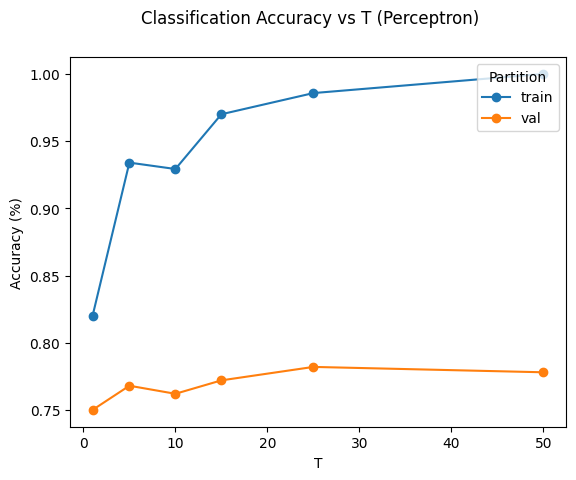

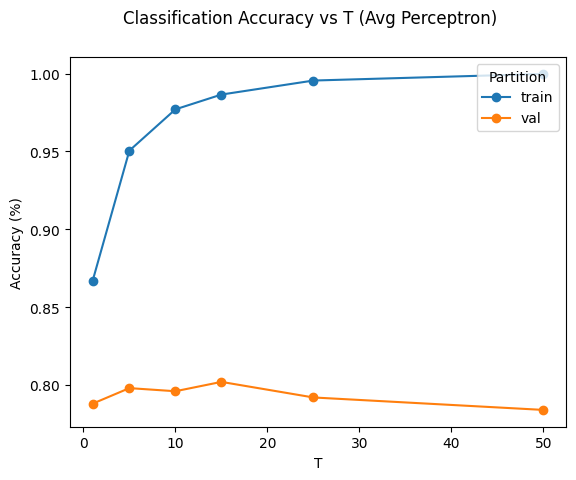

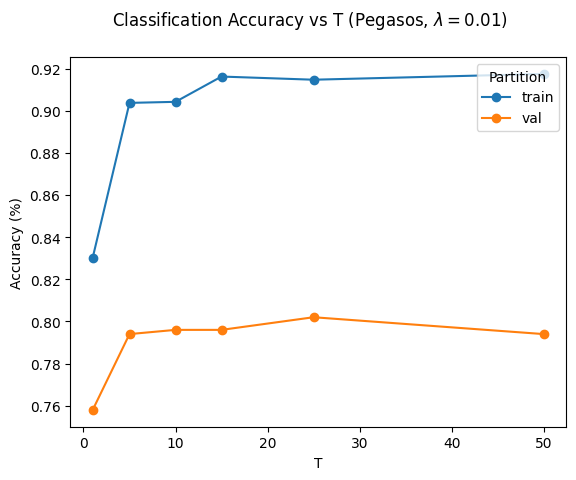

In [7]:
# -----------------------------------------------------------------------------
# Hyperparameter tuning
# -----------------------------------------------------------------------------

data = (train_bow_features, train_labels, val_bow_features, val_labels)

# Values of T and lambda to try
Ts = np.array([1, 5, 10, 15, 25, 50])
Ls = np.array([0.0001, 0.001, 0.01, 0.1, 1])

pct_tune_results = utils.tune_perceptron(Ts, *data)
print('Best Perceptron: Accuracy = {:.4f}, T={:.4f}'.format(np.max(pct_tune_results[1]), Ts[np.argmax(pct_tune_results[1])]))
avg_pct_tune_results = utils.tune_avg_perceptron(Ts, *data)
print('Best Average Perceptron: Accuracy = {:.4f}, T={:.4f}'.format(np.max(avg_pct_tune_results[1]), Ts[np.argmax(avg_pct_tune_results[1])]))
peg_train_accs, peg_val_accs, best_peg_T, best_peg_L = utils.tune_pegasos(Ts, Ls, *data)
print('Best Pegasos: Accuracy = {:.4f}, T={}, L={:.4g}'.format(np.max(peg_val_accs), best_peg_T, best_peg_L))

utils.plot_tune_results('Perceptron', 'T', Ts, *pct_tune_results)
utils.plot_tune_results('Avg Perceptron', 'T', Ts, *avg_pct_tune_results)
fix_L = 0.01
peg_tune_results_T = utils.tune(lambda features, labels, T: core.pegasos(features, labels, T, fix_L), Ts, *data)
utils.plot_tune_results(r'Pegasos, $\lambda=0.01$', 'T', Ts, *peg_tune_results_T)

### Performance after tuning

After tuning, the best validation results are:

| Algorithm | Best $T$ | Best $\lambda$ | Validation accuracy |
|---|---:|---:|---:|
| Perceptron | $25$ | — | $0.7820$ |
| Average Perceptron | $15$ | — | $0.8020$ |
| Pegasos | $25$ | $0.01$ | $0.8020$ |

Tuning improves the comparison relative to the baseline experiment. The Perceptron improves, but it still remains below the Average Perceptron and Pegasos. The Average Perceptron and Pegasos reach the same validation accuracy in this run. Since the validation scores of the Average Perceptron and Pegasos are tied, the final selected model is determined by the tie-breaking behavior in the code. The important conclusion is that the best two models have very similar performance, which is reasonable because all three methods are linear classifiers trained on the same bag-of-words representation.

## Accuracy on the test set

After the best method and its parameters have been chosen using validation accuracy, the selected classifier is evaluated on the test set. The validation set is used for tuning hyperparameters, while the held-out test set is the final benchmark. It is normal for the validation and test accuracies not to match exactly, because they are measured on different data splits. If the best validation scores for the three model families are

$$
A_{\mathrm{perc}},\qquad A_{\mathrm{avg}},\qquad A_{\mathrm{peg}},
$$

then the selected model family is the one with the largest of these validation scores. Only that final model is then evaluated on the test data.

In [8]:
# -------------------------------------------------------------------------------
# Final model selection and test evaluation
# -------------------------------------------------------------------------------

best_pct = np.max(pct_tune_results[1])
best_avg_pct = np.max(avg_pct_tune_results[1])
best_peg = np.max(peg_val_accs)

method_accuracies = [best_pct, best_avg_pct, best_peg]
methods = ['Perceptron', 'Average Perceptron', 'Pegasos']

best_method = np.argmax(method_accuracies)

if best_method == 0:
    T = Ts[np.argmax(pct_tune_results[1])]
    theta, theta_0 = core.perceptron(train_bow_features, train_labels, T)
elif best_method == 1:
    T = Ts[np.argmax(avg_pct_tune_results[1])]
    theta, theta_0 = core.average_perceptron(train_bow_features, train_labels, T)
elif best_method == 2:
    T = best_peg_T
    L = best_peg_L
    theta, theta_0 = core.pegasos(train_bow_features, train_labels, T, L)

predictions = core.classify(test_bow_features, theta, theta_0)
test_accuracy = core.accuracy(predictions, test_labels)
print(methods[best_method] + ': ' + str(test_accuracy))

Average Perceptron: 0.784


### Test-set conclusion

The selected model is evaluated once on the held-out test set. In this run, the selected model is the Average Perceptron, with test accuracy

$$
\mathrm{Acc}_{\mathrm{test}}=0.7840.
$$

The test accuracy is not identical to the validation accuracy. This is expected because the validation set is used for model selection, while the test set is a separate benchmark for the final chosen model. The result suggests that a linear classifier with bag-of-words features gives a reasonable sentiment-classification baseline, but the model is still limited by the simplicity of the representation. The later feature-engineering experiment checks whether changing the representation can improve performance.

## Most explanatory unigrams

For a linear text classifier, each coordinate of $\theta$ corresponds to one word in the dictionary. Large positive entries of $\theta$ indicate words that push the classifier toward the positive label, while large negative entries push the classifier toward the negative label. If word $w_j$ corresponds to coordinate $j$, then:

- large positive $\theta_j$ makes positive classification more likely
- large negative $\theta_j$ makes negative classification more likely

Sorting the learned coefficients therefore identifies the most explanatory unigram features for each class.

In [9]:
# -------------------------------------------------------------------------------
# Inspect the most informative learned features
# -------------------------------------------------------------------------------

best_theta = theta
wordlist = [word for (idx, word) in sorted(zip(dictionary.values(), dictionary.keys()))]

sorted_word_features = utils.most_explanatory_word(best_theta, wordlist)
print("Most Explanatory Word Features")
print(sorted_word_features[:10])

sorted_word_features_neg = utils.most_explanatory_word(-best_theta, wordlist)
print("Most Explanatory Word Features for Negative Labels")
print(sorted_word_features_neg[:10])

Most Explanatory Word Features
['perfect', 'perfectly', 'delicious', 'glad', 'bottle', 'originally', 'protein', 'reasonable', 'pleased', 'great']
Most Explanatory Word Features for Negative Labels
['disappointment', 'worst', 'disappointed', 'unfortunately', 'horrible', 'awful', 'dont', 'including', 'ball', 'disgusting']


### Interpretation of learned word features

The most positive word features include words such as `perfect`, `perfectly`, `delicious`, `glad`, `pleased`, and `great`. These are naturally associated with favorable product reviews. The most negative word features include words such as `disappointment`, `worst`, `disappointed`, `unfortunately`, `horrible`, `awful`, and `disgusting`. These words are naturally associated with unfavorable reviews. This confirms that the learned linear classifier is interpretable: large positive coefficients correspond to words that push the prediction toward the positive class, while large negative coefficients correspond to words that push the prediction toward the negative class.

## Feature Engineering

The way the data is represented can have a significant impact on the performance of a machine-learning method. The final experiment keeps the learning algorithm fixed and changes the bag-of-words representation. First, stopword removal changes the dictionary by removing words in the stopword list:

$$
V_{\mathrm{filtered}}=V - S,
$$

where $S$ is the set of stopwords. Second, the feature vector can store either binary indicators or word counts. Binary features use

$$
x_j=\mathbf{1}\{w_j\text{ appears in the review}\},
$$

while count features use

$$
x_j=\#\{\text{occurrences of }w_j\text{ in the review}\}.
$$

More information does not always improve performance: count features may introduce irrelevant variation and can lead to worse generalization than binary indicators.

In [10]:
# -------------------------------------------------------------------------------
# Feature engineering experiment
# -------------------------------------------------------------------------------

dictionary = core.bag_of_words(train_texts, remove_stopword=True)

# Remove Stop Words
train_bow_features = core.extract_bow_feature_vectors(train_texts, dictionary)
test_bow_features = core.extract_bow_feature_vectors(test_texts, dictionary)

T = 25; L = 0.01
theta, theta_0 = core.pegasos(train_bow_features, train_labels, T, L)
predictions = core.classify(test_bow_features, theta, theta_0)
test_accuracy = core.accuracy(predictions, test_labels)
print('Pegasos with "stopwords" removed, Binary Features: ' + str(test_accuracy))

# Change Binary Features to Counts Features
train_bow_features = core.extract_bow_feature_vectors(train_texts, dictionary, binarize=False)
test_bow_features = core.extract_bow_feature_vectors(test_texts, dictionary, binarize=False)

T = 25; L = 0.01
theta, theta_0 = core.pegasos(train_bow_features, train_labels, T, L)
predictions = core.classify(test_bow_features, theta, theta_0)
test_accuracy = core.accuracy(predictions, test_labels)
print('Pegasos with "stopwords" removed, Counts Features: ' + str(test_accuracy))

Pegasos with "stopwords" removed, Binary Features: 0.808
Pegasos with "stopwords" removed, Counts Features: 0.776


### Feature Engineering results and conclusions

Keeping Pegasos fixed with $T=25$ and $\lambda=0.01$, the feature-engineering experiment gives:

| Feature representation | Test accuracy |
|---|---:|
| Stopwords removed, binary features | $0.8080$ |
| Stopwords removed, count features | $0.7760$ |

The best result in this feature-engineering comparison is obtained by removing stopwords and keeping binary bag-of-words features. This representation records whether a word appears in a review, but does not increase the feature value when the word appears multiple times. The count-feature representation performs worse in this run. This shows that adding more numerical information to the feature vector does not automatically improve performance. Word counts can introduce irrelevant variation and may cause the classifier to emphasize repeated words in a way that does not generalize as well. The conclusion is that, for this dataset and these linear classifiers, a simple binary bag-of-words representation with stopword removal is more effective than count-based features.

## Summary of results and conclusions

This notebook builds an automatic review analyzer by combining bag-of-words text features with linear classification algorithms. The main steps were:

- load the review data and labels,
- convert reviews into bag-of-words feature vectors,
- train Perceptron, Average Perceptron, and Pegasos classifiers,
- compare baseline training and validation accuracy,
- tune $T$ and $\lambda$ using validation performance,
- evaluate the selected model on the held-out test set,
- inspect the most explanatory positive and negative word features,
- compare simple feature-engineering variants.

The baseline comparison showed that the Average Perceptron and Pegasos outperform the ordinary Perceptron on validation accuracy. After tuning, the Average Perceptron and Pegasos reached the same best validation accuracy, while the ordinary Perceptron remained slightly weaker.

The final selected model was evaluated on the held-out test set, giving a test accuracy of $0.7840$ in this run. The difference between validation and test accuracy is expected because the test set is a separate benchmark that is not used during tuning.

The feature-engineering experiment showed that stopword removal with binary bag-of-words features gives the strongest result among the tested representations, with test accuracy $0.8080$. Changing from binary indicators to count features reduced accuracy to $0.7760$, showing that more detailed feature values do not necessarily improve generalization.

The learned word weights are also interpretable: positive coefficients correspond to words such as `perfect`, `delicious`, and `great`, while negative coefficients correspond to words such as `disappointment`, `worst`, and `awful`.

Overall, the project shows that simple linear classifiers can produce a clear and interpretable sentiment-analysis pipeline, but performance depends strongly on hyperparameter tuning and on how the text is represented.